# M33 notebook 3: save list of peaks

This notebook will have to be run separately for each field. 

Before this, need to run notebooks 2a and 2b which make all the maps needed for the detection.

Play with map of peak detection, once happy with detection save list of peaks.

In [1]:
field = 'SW'
dig_map_exists = False

In [2]:
# Parameters
field = "F6"


In [3]:
%matplotlib inline

import numpy as np
import astropy.io.fits as fits
#from scipy.ndimage import median_filter, uniform_filter, minimum_filter, maximum_filter, convolve, standard_deviation
from scipy.ndimage import median_filter, uniform_filter, standard_deviation
from scipy.ndimage import gaussian_laplace
from scipy.ndimage import generic_filter
import scipy.ndimage as ndimage
from scipy import stats
from matplotlib.colors import LogNorm

from astropy.table import QTable
from astropy.table import Table
import sys
import json
import os

# import orb as orb
# from orcs.process import SpectralCube
# import orb.utils.image

from time import perf_counter as clock
import matplotlib.pyplot as plt
from datetime import datetime

import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [4]:
def readdata(file):
    data,hdr = fits.getdata(file,header=True)
    print('Reading: ',file,data.shape)
    return data,hdr

    
def makeplot(log,col,imagein,imagevvi,xi,xf,yi,yf,a,vvimin,vvimax,cbartit):
    plt.rcParams['axes.linewidth'] = 2
    plt.tick_params(axis='both', direction='in',   labelsize=20, length=6, width=2)
    plt.axis([xi,xf,yi,yf])
    if col != 0: couleur = 'rainbow'
    if col == 0: couleur = 'gray'
    if log == 1: 
        vvi=np.log10(imagevvi[yi:yf,xi:xf])
        plt.imshow(np.log10(imagein), cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if log != 1: 
        vvi=imagevvi[yi:yf,xi:xf]
        plt.imshow(imagein, cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    cbar=plt.colorbar(pad=0.01)
    cbar.ax.tick_params(labelsize=20)
    if cbartit != '': cbar.set_label(cbartit, size=25)
    return


In [5]:
sizebox = 1

# xi, xf, yi, yf = np.array(data_paths_dict['Image portion xi,xf,yi,yf'])
xi,xf,yi,yf = np.loadtxt(f'peak_files/param_sections/param_section_{sizebox}_{field}.txt', unpack=True)
#convert to int
xi,xf,yi,yf = int(xi), int(xf), int(yi), int(yf)

print('Image portion XY:', xi,xf,yi,yf)



directory = '../M33-Maps/M33-{}/'.format(field)

print()
print('SN3: ')
im_amp,header3 = readdata(directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits'.format(field))
im_amp_noi,hea = readdata(directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits'.format(field))

# im_amp,header3 = readdata(directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude.fits'.format(field))
# im_amp_noi,hea = readdata(directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude-err.fits'.format(field))

im_amp_snr = im_amp/im_amp_noi
maskbg3,hea    = readdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/SNR3.fits')
starvalue      = 0
print('Starvalue = ', starvalue)
im_amp_s       = np.copy(im_amp)
im_amp_s[maskbg3 == starvalue] = np.nan
im_amp_snr_s       = np.copy(im_amp_snr)
im_amp_snr_s[maskbg3 == starvalue] = np.nan
print('Amplitude file with stars = nan')
fluxha,hdr = readdata(directory+'M33{}-Haflux.fits'.format(field))
fluxha[maskbg3 == starvalue] = np.nan 


print()
im_amp3_s,hea       = readdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/AMP_sizd{sizebox}.fits') # 5x5 and Stars are nan
im_amp3_m,hea       = readdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/M33_{field}_HaOIII_amp_nonan.fits') # 5x5 and Stars are median
im_amp3_snr_s,hea   = readdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/SNR3.fits')

print()

# file = f'peak_files/data_for_visualisation_OIII+Ha_{field}/A_PicL17_sizd{sizebox}.fits'
# im_pic, hea = readdata(file)
# ypic,xpic = np.where(im_pic == 1)
# npic = len(xpic)
# idpic = np.arange(0,len(xpic),1)
# idpic = np.array(idpic)
# print('Nb pic in detection fits file ',file,': ',len(xpic))

print()
Folder_data = f'peak_files/2-BG_Noi_Th_data_OIII+Ha_{field}/'
if os.path.isdir(Folder_data) == False:
    os.mkdir(Folder_data)
    print('Folder created: ', Folder_data)
else:
    print('Folder exists already: ', Folder_data)

Folder_fig = f'plots/peak_plots/'
if os.path.isdir(Folder_fig) == False:
    os.mkdir(Folder_fig)
    print('Folder created: ', Folder_fig)
else:
    print('Folder exists already: ', Folder_fig)

Image portion XY: 50 2000 50 2000

SN3: 
Reading:  ../M33-Maps/M33-F6/M33-F6_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits (2064, 2048)
Reading:  ../M33-Maps/M33-F6/M33-F6_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits (2064, 2048)
Reading:  peak_files/data_for_visualisation_OIII+Ha_F6/SNR3.fits (2064, 2048)
Starvalue =  0
Amplitude file with stars = nan
Reading:  ../M33-Maps/M33-F6/M33F6-Haflux.fits (2064, 2048)

Reading:  peak_files/data_for_visualisation_OIII+Ha_F6/AMP_sizd1.fits (2064, 2048)
Reading:  peak_files/data_for_visualisation_OIII+Ha_F6/M33_F6_HaOIII_amp_nonan.fits (2064, 2048)
Reading:  peak_files/data_for_visualisation_OIII+Ha_F6/SNR3.fits (2064, 2048)


Folder exists already:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F6/
Folder exists already:  plots/peak_plots/


In [6]:

# Hα global LogNorm scaling helpers (for saved plots)
valid_pos = im_amp_s[np.isfinite(im_amp_s) & (im_amp_s > 0)]
if valid_pos.size == 0:
    raise ValueError("Hα map has no positive finite values for LogNorm.")
vmin_global = np.nanpercentile(valid_pos, 5)
vmax_global = np.nanpercentile(valid_pos, 99)
if (not np.isfinite(vmin_global)) or (not np.isfinite(vmax_global)) or (vmax_global <= vmin_global):
    vmin_global, vmax_global = np.nanmin(valid_pos), np.nanmax(valid_pos)
    if not np.isfinite(vmin_global) or not np.isfinite(vmax_global) or vmax_global <= vmin_global:
        raise ValueError("Failed to compute valid global vmin/vmax for Hα.")
# Per-cutout LogNorm for saved plots
P_LO, P_HI = 3.0, 99.7
MIN_POS_PIX = 20
EPS_POS = np.nextafter(0, 1)    
def local_lognorm(cutout, p_lo=P_LO, p_hi=P_HI, min_pos_pixels=MIN_POS_PIX):
    pos = cutout[np.isfinite(cutout) & (cutout > 0)]
    vmin_loc, vmax_loc = vmin_global, vmax_global
    if pos.size >= min_pos_pixels:
        lo = np.nanpercentile(pos, p_lo)
        hi = np.nanpercentile(pos, p_hi)
        if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
            vmin_loc, vmax_loc = lo, hi
    vmin_loc = max(vmin_loc, EPS_POS)
    if not np.isfinite(vmax_loc) or vmax_loc <= vmin_loc:
        vmax_loc = vmin_loc * 1.01
    return LogNorm(vmin=vmin_loc, vmax=vmax_loc)


peak_files/data_for_visualisation_OIII+Ha_F6/A_PicL15_sizd10.fits  :  6339
SNRlim  6  :  2949
+Thre bgbox/std/sig  30 / 3 / 3.0  :  1370


Saved to plots/peak_plots/


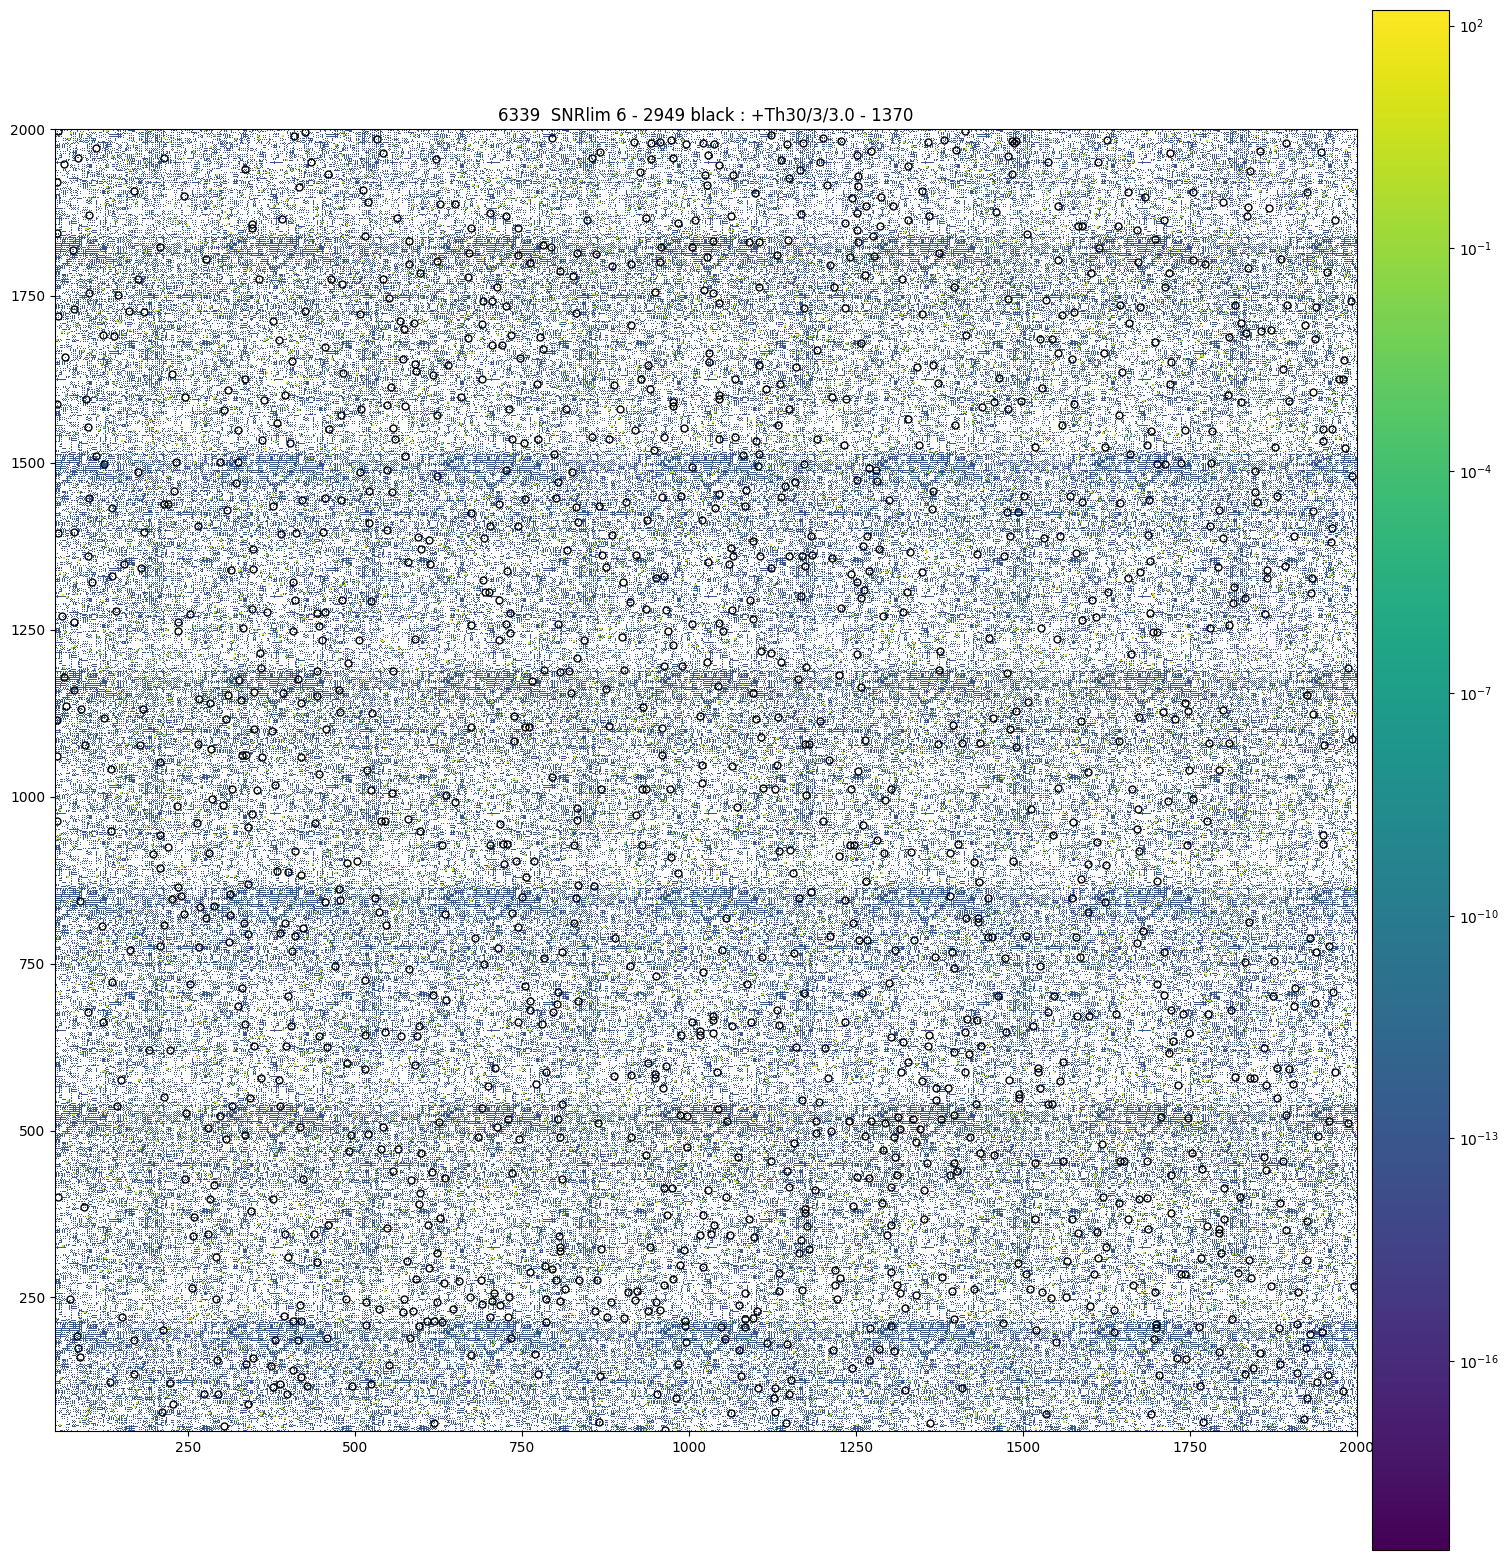

In [7]:
## TH
lap = 15
filepeak = f'peak_files/data_for_visualisation_OIII+Ha_{field}/A_PicL{lap}_sizd10.fits'
im_pic   = fits.getdata(filepeak)
ypic,xpic = np.where(im_pic == 1)
npic=len(xpic)
print(filepeak,' : ',npic)

snrlim = 6

im_picsnr = np.copy(im_pic)
im_picsnr[im_amp3_snr_s  < snrlim] = np.nan
ypicsnr,xpicsnr = np.where(im_picsnr == 1)
npicsnr   = len(xpicsnr)
print('SNRlim ',snrlim,' : ',npicsnr)

bgbox  = 30
stdbox = 3
signoi = 3.0 #has to be a float
file   = f'{Folder_data}Th_box{bgbox}_std{stdbox}_signoi{signoi}.fits'
thres  = fits.getdata(file)
difthr = im_amp3_s - thres
im_picth = np.copy(im_picsnr)
im_picth[difthr <=0]  = np.nan
ypicth,xpicth = np.where(im_picth == 1)
npicth = len(xpicth)
print('+Thre bgbox/std/sig ',bgbox,'/',stdbox,'/',signoi,' : ',npicth)

if dig_map_exists:
    filedig  = f'../M33-Maps/M33-{field}/DIG_Ha_penalty0_limmed1.5_sigma1_power_weight_2_size_box_20_bgconst.fits'
    digha    = fits.getdata(filedig)
    fluxcube = fits.getdata(f'../M33-Maps/M33-{field}/M33_Field2_cube.fits')
    fluxha_dig  = np.copy(fluxcube[0])
    difdig = fluxha_dig - digha
    im_picdig = np.copy(im_picth)
    im_picdig[difdig <= 0 ] = np.nan
    ypicdig,xpicdig = np.where(im_picdig == 1)
    npicdig   = len(xpicdig)
    print('+DIG : ',npicdig)

# %matplotlib qt
sizone = 1000
xcen = [ 1000] #, 1150,1350,  850,1050,1250,1450,  775,975,1175,1375, 675,875,1075,1275]
ycen = [ 1000] #, 1350,1350, 1150,1150,1150,1150,  950,950, 950, 950, 750,750, 750, 750]

nyy, nxx, ip = 1,1,0
fig1 = plt.figure(figsize=(20*nxx,20*nyy))
fig1.subplots_adjust(hspace=0.1,wspace=-0.1)

for i in range(len(xcen)):
    ip=ip+1
    # xp1,xp2,yp1,yp2 =xcen[i]-sizone, xcen[i]+sizone, ycen[i]-sizone, ycen[i]+sizone
    xp1,xp2,yp1,yp2 = xi,xf,yi,yf
    ax=plt.subplot(nyy,nxx,ip)
    plt.axis([xp1,xp2,yp1,yp2]) #plt.axis([xi,xf,yi,yf])
    # plt.imshow(np.log10(im_amp_s),origin='lower',vmin=-20,vmax=-15)
    plt.imshow(im_amp, origin="lower", norm=local_lognorm(im_amp_s))
    cbar=plt.colorbar(pad=0.01)
    # plt.plot(xpic,ypic,'x',color='black',  ms=5,zorder=1)
    # plt.plot(xpicsnr,ypicsnr,'x',color='cyan', ms=5,zorder=2)
    plt.plot(xpicth,ypicth,'.',color='k', markerfacecolor='none',ms=10,zorder=3)
    # plt.plot(xpicdig,ypicdig,'o',color='red', ms=3,zorder=4)
    
        
    # plt.title('black : L14 - '+str(npic)+'  cyan : SNRlim '+str(snrlim)+' - '+str(npicsnr)+
    #          '   orange : +Th'+str(bgbox)+'/'+str(stdbox)+'/'+str(signoi)+' - '+str(npicth)+
    #          '   red : +DIG - '+str(npicdig))
    
    plt.title(str(npic)+ '  SNRlim '+str(snrlim)+' - '+str(npicsnr)+
            ' black : +Th'+str(bgbox)+'/'+str(stdbox)+'/'+str(signoi)+' - '+str(npicth))
    plt.savefig(Folder_fig+f'Peaks_{field}_{snrlim}_{signoi}_L{lap}_{bgbox}_{stdbox}_{signoi}.jpeg',bbox_inches = 'tight')
    print(f'Saved to {Folder_fig}')



In [8]:
# Output folder
outdir = "final_peak_info"
os.makedirs(outdir, exist_ok=True)

# Helper: safe string for filenames
def _sf(x):
    # keep floats readable and filesystem-safe
    if isinstance(x, float):
        s = f"{x:g}"
    else:
        s = str(x)
    return s.replace(".", "p")

# Build a parameter tag for filenames
param_tag = (
    f"field{field}"
    f"_L{lap}"
    f"_snr{_sf(snrlim)}"
    f"_bg{bgbox}"
    f"_std{stdbox}"
    f"_signoi{_sf(signoi)}"
)

# Collect TH peaks (final list you want)
y_th = np.array(ypicth, dtype=int)
x_th = np.array(xpicth, dtype=int)

if dig_map_exists:
    # Determine which TH peaks survive the DIG cut
    # Approach: turn DIG peaks into a set of (y,x) for fast membership checks
    dig_set = set(zip(np.array(ypicdig, dtype=int), np.array(xpicdig, dtype=int)))
    kept_after_dig = np.fromiter(((y, x) in dig_set for y, x in zip(y_th, x_th)),
                                dtype=bool, count=len(y_th))

    # Make dataframe
    df = pd.DataFrame({
        "field": [field] * len(x_th),
        "y": y_th,
        "x": x_th,
        "kept_after_DIG": kept_after_dig
    })

    csv_name = f"peaks_TH_with_DIGflag_{param_tag}.csv"
    csv_path = os.path.join(outdir, csv_name)
else:
    # If no DIG map, just save the TH peaks without the flag
    df = pd.DataFrame({
        "field": [field] * len(x_th),
        "y": y_th,
        "x": x_th
    })

    csv_name = f"peaks_TH_{param_tag}.csv"
    csv_path = os.path.join(outdir, csv_name)

with open(csv_path, "w") as f:
    # --- Metadata header ---
    f.write("# =============================================\n")
    f.write("# Peak catalogue for HII region identification\n")
    f.write("# =============================================\n")
    f.write(f"# field   = {field}\n")
    f.write(f"# lap     = {lap}\n")
    f.write(f"# snrlim  = {snrlim}\n")
    f.write(f"# bgbox   = {bgbox}\n")
    f.write(f"# stdbox  = {stdbox}\n")
    f.write(f"# signoi  = {signoi}\n")
    f.write("\n")
    
    # --- Write table ---
    df.to_csv(f, index=False)

print("Saved CSV with metadata header:", csv_path)

# Save a human-readable parameter log
txt_name = f"parameters_{param_tag}.txt"
txt_path = os.path.join(outdir, txt_name)

lines = []
lines.append(f"Created: {datetime.now().isoformat(timespec='seconds')}")
lines.append("")
lines.append("=== Field / parameters ===")
lines.append(f"field   = {field}")
lines.append(f"lap     = {lap}")
lines.append(f"snrlim  = {snrlim}")
lines.append(f"bgbox   = {bgbox}")
lines.append(f"stdbox  = {stdbox}")
lines.append(f"signoi  = {signoi}")
lines.append("")
lines.append("=== Input files used (as defined in your notebook) ===")
# Only write these if they exist in the namespace; avoids NameError if you rename variables
for varname in ["filepeak", "file", "filedig"]:
    if varname in globals():
        lines.append(f"{varname} = {globals()[varname]}")
lines.append("")
lines.append("=== Peak counts ===")
lines.append(f"n_TH_peaks          = {len(x_th)}")
# lines.append(f"n_survive_DIG       = {int(kept_after_dig.sum())}")
# lines.append(f"n_removed_by_DIG    = {int((~kept_after_dig).sum())}")
lines.append("")
lines.append("=== Output files ===")
lines.append(f"csv = {csv_path}")
lines.append(f"txt = {txt_path}")

with open(txt_path, "w") as f:
    f.write("\n".join(lines) + "\n")

print("Saved:")
print(" -", csv_path)
print(" -", txt_path)
# print(f"TH peaks: {len(x_th)} | survive DIG: {int(kept_after_dig.sum())} | removed by DIG: {int((~kept_after_dig).sum())}")

Saved CSV with metadata header: final_peak_info/peaks_TH_fieldF6_L15_snr6_bg30_std3_signoi3.csv
Saved:
 - final_peak_info/peaks_TH_fieldF6_L15_snr6_bg30_std3_signoi3.csv
 - final_peak_info/parameters_fieldF6_L15_snr6_bg30_std3_signoi3.txt
